# Processing of a resting-state EEG dataset for sleep deprivation

Bad channels are interpolated

## PRE PROCESSING

#### The intention is to provide epochs(4 seconds) to the machine and try predicting if the case is sleep deprivation or normal sleep.

In [1]:
from matplotlib import pyplot as plt
import os
import pandas as pd
import numpy as np
from scipy import signal
import mne
import mne_icalabel
from mne.preprocessing import ICA
from autoreject import Ransac  
from mne_icalabel import label_components
%matplotlib inline

In [2]:
# lists to collect data
X_frontal_train_list = []
X_temporal_train_list = []
X_parietal_train_list = []
X_occipital_train_list = []
X_central_train_list = []

y_frontal_train_list = []
y_temporal_train_list = []
y_parietal_train_list = []
y_occipital_train_list = []
y_central_train_list = []

X_test_list = []
X_frontal_test_list = []
X_temporal_test_list = []
X_parietal_test_list = []
X_occipital_test_list = []
X_central_test_list = []

y_test_list = []
y_frontal_test_list = []
y_temporal_test_list = []
y_parietal_test_list = []
y_occipital_test_list = []
y_central_test_list = []

In [3]:
n_epochs = 0
for i in range(1, 72):
    if i == 28 or i== 1 or i== 44 or i==39 or i==43 or i in [7,8,11,18,24,29,31,35,36,37,38,40,47,48,50,54,63,67,70,71]: #46
        continue  # Skip participants due to missing data
    for j in range(1, 3):
        
        #Define file path
        file_path = f'D:\\BCI\\TASKS\\Task-8\\ds004902_data\\sub-{i:02d}\\ses-{j}\\eeg\\sub-{i:02d}_ses-{j}_task-eyesopen_eeg.set'#The d indicates that the value is a decimal integer, while the 02 specifies that the output should be padded with leading zeros if necessary to reach a width of two characters.
        epochs_file = f'D:\\BCI\\TASKS\\Task-8\\processed_epochs_60\\sub-{i:02d}_ses-{j}_epochs.fif'  # Path to save/load processed epochs

        
        eeg_channels = ["Fp1", "AF3", "AF7", "Fz", "F1", "F3", "F5", "F7","FC1", "FC3", "FC5", "FT7","Cz", "C1", "C3", "C5", "T7","CP1", "CP3", "CP5", "TP7", "TP9","Pz", "P1", "P3", "P5", "P7","PO3", "PO7", "Oz", "O1","Fpz", "Fp2", "AF4", "AF8","F2", "F4", "F6", "F8","FC2", "FC4", "FC6", "FT8","C2", "C4", "C6", "T8","CPz", "CP2", "CP4", "CP6","TP8", "TP10","P2", "P4", "P6", "P8","POz", "PO4", "PO8", "O2"]
               
        if os.path.exists(epochs_file):
            print(f"Loading processed epochs from {epochs_file}")
            epochs = mne.read_epochs(epochs_file, preload=True)
        else:
            print(f"\nProcessing: {file_path}\n")

            #Define EEG channels
            eeg_channels = ["Fp1", "AF3", "AF7", "Fz", "F1", "F3", "F5", "F7","FC1", "FC3", "FC5", "FT7","Cz", "C1", "C3", "C5", "T7","CP1", "CP3", "CP5", "TP7", "TP9","Pz", "P1", "P3", "P5", "P7","PO3", "PO7", "Oz", "O1","Fpz", "Fp2", "AF4", "AF8","F2", "F4", "F6", "F8","FC2", "FC4", "FC6", "FT8","C2", "C4", "C6", "T8","CPz", "CP2", "CP4", "CP6","TP8", "TP10","P2", "P4", "P6", "P8","POz", "PO4", "PO8", "O2"]
            
            #Load EEG data
            raw = mne.io.read_raw_eeglab(file_path, preload=True)
            eeg_raw=raw.pick(mne.pick_channels(raw.info['ch_names'], include=eeg_channels))
            
            #Montage setting
            montage = mne.channels.make_standard_montage('standard_1020')
            eeg_raw.set_montage(montage)

            #Filtering
            eeg_raw.filter(1., 40.)#, fir_design='firwin')

            #Average Referencing
            eeg_raw.set_eeg_reference('average', projection=True)
            eeg_raw.apply_proj()
            
            #EPOCHING
            epochs = mne.make_fixed_length_epochs(eeg_raw, duration=4.0, overlap=0.0,preload=True)
            
            #RANSAC for bad channel detection
            ransac = Ransac(verbose=False, n_jobs=1)
            ransac.fit(epochs)
            raw.info['bads'].extend(ransac.bad_chs_)   

            #interpolate bad channels
            raw.interpolate_bads(reset_bads=True)

            
            #ICA for artifact removal
            ica = mne.preprocessing.ICA(n_components=20, method='infomax', fit_params=dict(extended=True), random_state=42, max_iter=1000)
            ica.fit(epochs)

            ic_labels = label_components(epochs, ica, method='iclabel')
            exclude_idx = []
            for idx, label in enumerate(ic_labels["labels"]):
                if label not in ["brain","other","muscle artifact"] and ic_labels["y_pred_proba"][idx] > 0.5:
                    exclude_idx.append(idx)

            ica.apply(epochs,exclude= exclude_idx)        

            # Save processed epochs
            os.makedirs(os.path.dirname(epochs_file), exist_ok=True) #creates the necessary directories for the file path if they don't exist.
            epochs.save(epochs_file, overwrite=True)
            print(f"Saved processed epochs to {epochs_file}")

        if j==1:
            labels = 0
        elif j==2:
            labels = 1
        labels = pd.DataFrame({'label': [labels]*len(epochs)})

        # Extract data and labels
        data = epochs.get_data()  # shape: (n_epochs, n_channels, n_times)

        # 1. Frontal: 
        frontal_eeg_channels = [ch for ch in eeg_channels if ch.startswith(('Fp', 'AF', 'F', 'FC')) and not ch.startswith('FT')] 
        data_frontal = epochs.copy().pick(frontal_eeg_channels)

        # 2. Temporal: 
        temporal_eeg_channels = [ch for ch in eeg_channels if ch.startswith(('T', 'FT', 'TP'))]
        data_temporal = epochs.copy().pick(temporal_eeg_channels)

        # 3. Parietal: 
        parietal_eeg_channels = [ch for ch in eeg_channels if ch.startswith(('P', 'CP', 'PO'))]
        data_parietal = epochs.copy().pick(parietal_eeg_channels)

        # 4. Occipital:
        occipital_eeg_channels = [ch for ch in eeg_channels if ch.startswith('O')]
        data_occipital = epochs.copy().pick(occipital_eeg_channels)

        # 5. Central channels:
        central_channels = [ch for ch in eeg_channels if ch.startswith('C') and not ch.startswith('CP')]
        data_central = epochs.copy().pick(central_channels)              

        #if (i == 39 or i == 43) and j == 2:
        #    data = signal.decimate(data, 10, axis=2) # Downsample by a factor of 10 to match time points.

        epoch_labels = labels['label'].values  
        
        if i <= 56:  # Training data
            X_frontal_train_list.append(data_frontal.get_data())
            X_temporal_train_list.append(data_temporal.get_data())
            X_parietal_train_list.append(data_parietal.get_data())
            X_occipital_train_list.append(data_occipital.get_data())
            X_central_train_list.append(data_central.get_data())

            y_frontal_train_list.append(epoch_labels)
            y_temporal_train_list.append(epoch_labels)
            y_parietal_train_list.append(epoch_labels)
            y_occipital_train_list.append(epoch_labels)
            y_central_train_list.append(epoch_labels)

        else:  # Testing data
            X_frontal_test_list.append(data_frontal.get_data())
            X_temporal_test_list.append(data_temporal.get_data())
            X_parietal_test_list.append(data_parietal.get_data())
            X_occipital_test_list.append(data_occipital.get_data())
            X_central_test_list.append(data_central.get_data())

            y_frontal_test_list.append(epoch_labels)
            y_temporal_test_list.append(epoch_labels)
            y_parietal_test_list.append(epoch_labels)
            y_occipital_test_list.append(epoch_labels)
            y_central_test_list.append(epoch_labels)

# After the loop, concatenate into arrays
X_frontal_train = np.concatenate(X_frontal_train_list, axis=0)
X_temporal_train = np.concatenate(X_temporal_train_list, axis=0)
X_parietal_train = np.concatenate(X_parietal_train_list, axis=0)
X_occipital_train = np.concatenate(X_occipital_train_list, axis=0)
X_central_train = np.concatenate(X_central_train_list, axis=0)

y_frontal_train = np.concatenate(y_frontal_train_list, axis=0)
y_temporal_train = np.concatenate(y_temporal_train_list, axis=0)
y_parietal_train = np.concatenate(y_parietal_train_list, axis=0)
y_occipital_train = np.concatenate(y_occipital_train_list, axis=0)
y_central_train = np.concatenate(y_central_train_list, axis=0)

X_frontal_test = np.concatenate(X_frontal_test_list, axis=0)
X_temporal_test = np.concatenate(X_temporal_test_list, axis=0)
X_parietal_test = np.concatenate(X_parietal_test_list, axis=0)
X_occipital_test = np.concatenate(X_occipital_test_list, axis=0)
X_central_test = np.concatenate(X_central_test_list, axis=0)

y_frontal_test = np.concatenate(y_frontal_test_list, axis=0)
y_temporal_test = np.concatenate(y_temporal_test_list, axis=0)
y_parietal_test = np.concatenate(y_parietal_test_list, axis=0)
y_occipital_test = np.concatenate(y_occipital_test_list, axis=0)
y_central_test = np.concatenate(y_central_test_list, axis=0)

print("Training and testing data processing complete.")

Loading processed epochs from D:\BCI\TASKS\Task-8\processed_epochs_60\sub-02_ses-1_epochs.fif
Reading D:\BCI\TASKS\Task-8\processed_epochs_60\sub-02_ses-1_epochs.fif ...
    Found the data of interest:
        t =       0.00 ...   59998.00 ms
        0 CTF compensation matrices available
Not setting metadata
5 matching events found
No baseline correction applied
0 projection items activated


C:\Users\suvan\AppData\Local\Temp\ipykernel_19068\1967579232.py:16: RuntimeWarning: This filename (D:\BCI\TASKS\Task-8\processed_epochs_60\sub-02_ses-1_epochs.fif) does not conform to MNE naming conventions. All epochs files should end with -epo.fif, -epo.fif.gz, _epo.fif or _epo.fif.gz
  epochs = mne.read_epochs(epochs_file, preload=True)


Loading processed epochs from D:\BCI\TASKS\Task-8\processed_epochs_60\sub-02_ses-2_epochs.fif
Reading D:\BCI\TASKS\Task-8\processed_epochs_60\sub-02_ses-2_epochs.fif ...
    Found the data of interest:
        t =       0.00 ...   59998.00 ms
        0 CTF compensation matrices available
Not setting metadata
5 matching events found
No baseline correction applied
0 projection items activated


C:\Users\suvan\AppData\Local\Temp\ipykernel_19068\1967579232.py:16: RuntimeWarning: This filename (D:\BCI\TASKS\Task-8\processed_epochs_60\sub-02_ses-2_epochs.fif) does not conform to MNE naming conventions. All epochs files should end with -epo.fif, -epo.fif.gz, _epo.fif or _epo.fif.gz
  epochs = mne.read_epochs(epochs_file, preload=True)


Loading processed epochs from D:\BCI\TASKS\Task-8\processed_epochs_60\sub-03_ses-1_epochs.fif
Reading D:\BCI\TASKS\Task-8\processed_epochs_60\sub-03_ses-1_epochs.fif ...
    Found the data of interest:
        t =       0.00 ...   59998.00 ms
        0 CTF compensation matrices available
Not setting metadata
5 matching events found
No baseline correction applied
0 projection items activated


...

Not setting metadata
5 matching events found
No baseline correction applied
0 projection items activated
Loading processed epochs from D:\BCI\TASKS\Task-8\processed_epochs_60\sub-69_ses-1_epochs.fif
Reading D:\BCI\TASKS\Task-8\processed_epochs_60\sub-69_ses-1_epochs.fif ...
    Found the data of interest:
        t =       0.00 ...   59998.00 ms
        0 CTF compensation matrices available


C:\Users\suvan\AppData\Local\Temp\ipykernel_19068\1967579232.py:16: RuntimeWarning: This filename (D:\BCI\TASKS\Task-8\processed_epochs_60\sub-69_ses-1_epochs.fif) does not conform to MNE naming conventions. All epochs files should end with -epo.fif, -epo.fif.gz, _epo.fif or _epo.fif.gz
  epochs = mne.read_epochs(epochs_file, preload=True)


Not setting metadata
5 matching events found
No baseline correction applied
0 projection items activated
Loading processed epochs from D:\BCI\TASKS\Task-8\processed_epochs_60\sub-69_ses-2_epochs.fif
Reading D:\BCI\TASKS\Task-8\processed_epochs_60\sub-69_ses-2_epochs.fif ...
    Found the data of interest:
        t =       0.00 ...   59998.00 ms
        0 CTF compensation matrices available


C:\Users\suvan\AppData\Local\Temp\ipykernel_19068\1967579232.py:16: RuntimeWarning: This filename (D:\BCI\TASKS\Task-8\processed_epochs_60\sub-69_ses-2_epochs.fif) does not conform to MNE naming conventions. All epochs files should end with -epo.fif, -epo.fif.gz, _epo.fif or _epo.fif.gz
  epochs = mne.read_epochs(epochs_file, preload=True)


Not setting metadata
5 matching events found
No baseline correction applied
0 projection items activated
Training and testing data processing complete.


## FEATURE EXTRACTION 

In [4]:
from scipy import stats

In [5]:
#Time-domain feature extraction functions
def mean(sample_data):
    return np.mean(sample_data, axis=-1)

def std(sample_data):
    return np.std(sample_data, axis=-1)

def zscore(sample_data):
    return stats.zscore(sample_data, axis=-1)

def ptp(sample_data):
    return np.ptp(sample_data, axis=-1)

def min(sample_data):
    return np.min(sample_data, axis=-1)

def max(sample_data):
    return np.max(sample_data, axis=-1)

def var(sample_data):
    return np.var(sample_data, axis=-1)

def rms(sample_data):
    return np.sqrt(np.mean(sample_data**2, axis=-1))

def skewness(sample_data):
    return stats.skew(sample_data, axis=-1)   

def kurtosis(sample_data):
    return stats.kurtosis(sample_data, axis=-1)


def mean_square(sample_data):
    return np.mean(sample_data**2, axis=-1)

def hjorth_params(sample_data):
    first_deriv = np.diff(sample_data, axis=-1)
    second_deriv = np.diff(first_deriv, axis=-1)

    var_zero = var(sample_data)
    var_d1 = var(first_deriv)
    var_d2 = var(second_deriv)
    
    activity = var_zero
    mobility = np.sqrt(var_d1 / var_zero)
    complexity = np.sqrt(var_d2 / var_d1) / mobility
    
    return activity, mobility, complexity

In [6]:
# Frequency-domain feature extraction functions
def bandpower_delta(sample_data, fs=500, axis=-1):
    freqs, psd_values = signal.welch(sample_data, fs=fs, axis=axis)
    delta_band = (0.5, 4)
    mask = (freqs >= delta_band[0]) & (freqs <= delta_band[1])
    delta_power = np.trapezoid(psd_values[..., mask], freqs[mask], axis=axis)
    return delta_power

def bandpower_theta(sample_data, fs=500, axis=-1):
    freqs, psd_values = signal.welch(sample_data, fs=fs, axis=axis)
    theta_band = (4, 8)
    mask = (freqs >= theta_band[0]) & (freqs <= theta_band[1])
    theta_power = np.trapezoid(psd_values[..., mask], freqs[mask], axis=axis)
    return theta_power

def bandpower_alpha(sample_data, fs=500, axis=-1):
    freqs, psd_values = signal.welch(sample_data, fs=fs, axis=axis)
    alpha_band = (8, 13)
    mask = (freqs >= alpha_band[0]) & (freqs <= alpha_band[1])
    alpha_power = np.trapezoid(psd_values[..., mask], freqs[mask], axis=axis)
    return alpha_power  

def bandpower_beta(sample_data, fs=500, axis=-1):
    freqs, psd_values = signal.welch(sample_data, fs=fs, axis=axis)
    beta_band = (13, 30)
    mask = (freqs >= beta_band[0]) & (freqs <= beta_band[1])
    beta_power = np.trapezoid(psd_values[..., mask], freqs[mask], axis=axis)
    return beta_power       

def bandpower_gamma(sample_data, fs=500, axis=-1):
    freqs, psd_values = signal.welch(sample_data, fs=fs, axis=axis)
    gamma_band = (30, 40)
    mask = (freqs >= gamma_band[0]) & (freqs <= gamma_band[1])
    gamma_power = np.trapezoid(psd_values[..., mask], freqs[mask], axis=axis)
    return gamma_power

def spectral_entropy(sample_data, fs=500, axis=-1):
    freqs, psd_values = signal.welch(sample_data, fs=fs, axis=axis)
    psd_norm = psd_values / np.sum(psd_values, axis=axis, keepdims=True)
    spectral_entropy = -np.sum(psd_norm * np.log2(psd_norm + 1e-10), axis=axis)
    return spectral_entropy

In [7]:
def feature_concatination(sample_data):
    feature_vector = []
    
    # Time-domain features
    #feature_vector.append(mean(sample_data))
    #feature_vector.append(std(sample_data))
    #feature_vector.append(ptp(sample_data))
    #feature_vector.append(min(sample_data))
    #feature_vector.append(max(sample_data))
    #feature_vector.append(var(sample_data))
    #feature_vector.append(rms(sample_data))
    #feature_vector.append(skewness(sample_data))
    #feature_vector.append(kurtosis(sample_data))
    #activity, mobility, complexity = hjorth_params(sample_data)
    #feature_vector.append(activity)
    #feature_vector.append(mobility)
    #feature_vector.append(complexity)

    # Frequency-domain features
    feature_vector.append(bandpower_delta(sample_data))
    feature_vector.append(bandpower_theta(sample_data))
    feature_vector.append(bandpower_alpha(sample_data))
    feature_vector.append(bandpower_beta(sample_data))
    feature_vector.append(bandpower_gamma(sample_data))
    feature_vector.append(spectral_entropy(sample_data))
    
    return np.concatenate(feature_vector, axis=-1)

In [8]:
from tqdm import tqdm_notebook
X_frontal_train_features=[]
for datta in tqdm_notebook(X_frontal_train):
    features = feature_concatination(datta)
    X_frontal_train_features.append(features)

X_frontal_train_features=np.array(X_frontal_train_features)
X_frontal_train_features.shape

C:\Users\suvan\AppData\Local\Temp\ipykernel_19068\1380623671.py:3: TqdmDeprecationWarning: This function will be removed in tqdm==5.0.0
Please use `tqdm.notebook.tqdm` instead of `tqdm.tqdm_notebook`
  for datta in tqdm_notebook(X_frontal_train):


  0%|          | 0/349 [00:00<?, ?it/s]

(349, 132)

In [9]:
from tqdm import tqdm_notebook
X_occipital_train_features=[]
for datta in tqdm_notebook(X_occipital_train):
    features = feature_concatination(datta)
    X_occipital_train_features.append(features)

X_occipital_train_features=np.array(X_occipital_train_features)
X_occipital_train_features.shape

C:\Users\suvan\AppData\Local\Temp\ipykernel_19068\866642580.py:3: TqdmDeprecationWarning: This function will be removed in tqdm==5.0.0
Please use `tqdm.notebook.tqdm` instead of `tqdm.tqdm_notebook`
  for datta in tqdm_notebook(X_occipital_train):


  0%|          | 0/349 [00:00<?, ?it/s]

(349, 18)

In [10]:
from tqdm import tqdm_notebook
X_parietal_train_features=[]
for datta in tqdm_notebook(X_parietal_train):
    features = feature_concatination(datta)
    X_parietal_train_features.append(features)

X_parietal_train_features=np.array(X_parietal_train_features)
X_parietal_train_features.shape

C:\Users\suvan\AppData\Local\Temp\ipykernel_19068\1970390621.py:3: TqdmDeprecationWarning: This function will be removed in tqdm==5.0.0
Please use `tqdm.notebook.tqdm` instead of `tqdm.tqdm_notebook`
  for datta in tqdm_notebook(X_parietal_train):


  0%|          | 0/349 [00:00<?, ?it/s]

(349, 126)

In [11]:
from tqdm import tqdm_notebook
X_temporal_train_features=[]
for datta in tqdm_notebook(X_temporal_train):
    features = feature_concatination(datta)
    X_temporal_train_features.append(features)

X_temporal_train_features=np.array(X_temporal_train_features)
X_temporal_train_features.shape

C:\Users\suvan\AppData\Local\Temp\ipykernel_19068\3676965928.py:3: TqdmDeprecationWarning: This function will be removed in tqdm==5.0.0
Please use `tqdm.notebook.tqdm` instead of `tqdm.tqdm_notebook`
  for datta in tqdm_notebook(X_temporal_train):


  0%|          | 0/349 [00:00<?, ?it/s]

(349, 48)

In [12]:
from tqdm import tqdm_notebook
X_central_train_features=[]
for datta in tqdm_notebook(X_central_train):
    features = feature_concatination(datta)
    X_central_train_features.append(features)

X_central_train_features=np.array(X_central_train_features)
X_central_train_features.shape

C:\Users\suvan\AppData\Local\Temp\ipykernel_19068\2131398731.py:3: TqdmDeprecationWarning: This function will be removed in tqdm==5.0.0
Please use `tqdm.notebook.tqdm` instead of `tqdm.tqdm_notebook`
  for datta in tqdm_notebook(X_central_train):


  0%|          | 0/349 [00:00<?, ?it/s]

(349, 42)

In [13]:
from tqdm import tqdm_notebook
X_frontal_test_features=[]
for datta in tqdm_notebook(X_frontal_test):
    features = feature_concatination(datta)
    X_frontal_test_features.append(features)

X_frontal_test_features=np.array(X_frontal_test_features)
X_frontal_test_features.shape

C:\Users\suvan\AppData\Local\Temp\ipykernel_19068\3179063598.py:3: TqdmDeprecationWarning: This function will be removed in tqdm==5.0.0
Please use `tqdm.notebook.tqdm` instead of `tqdm.tqdm_notebook`
  for datta in tqdm_notebook(X_frontal_test):


  0%|          | 0/103 [00:00<?, ?it/s]

(103, 132)

In [14]:
from tqdm import tqdm_notebook
X_occipital_test_features=[]
for datta in tqdm_notebook(X_occipital_test):
    features = feature_concatination(datta)
    X_occipital_test_features.append(features)

X_occipital_test_features=np.array(X_occipital_test_features)
X_occipital_test_features.shape

C:\Users\suvan\AppData\Local\Temp\ipykernel_19068\2419268694.py:3: TqdmDeprecationWarning: This function will be removed in tqdm==5.0.0
Please use `tqdm.notebook.tqdm` instead of `tqdm.tqdm_notebook`
  for datta in tqdm_notebook(X_occipital_test):


  0%|          | 0/103 [00:00<?, ?it/s]

(103, 18)

In [15]:
from tqdm import tqdm_notebook
X_parietal_test_features=[]
for datta in tqdm_notebook(X_parietal_test):
    features = feature_concatination(datta)
    X_parietal_test_features.append(features)

X_parietal_test_features=np.array(X_parietal_test_features)
X_parietal_test_features.shape

C:\Users\suvan\AppData\Local\Temp\ipykernel_19068\3904372689.py:3: TqdmDeprecationWarning: This function will be removed in tqdm==5.0.0
Please use `tqdm.notebook.tqdm` instead of `tqdm.tqdm_notebook`
  for datta in tqdm_notebook(X_parietal_test):


  0%|          | 0/103 [00:00<?, ?it/s]

(103, 126)

In [16]:
from tqdm import tqdm_notebook
X_temporal_test_features=[]
for datta in tqdm_notebook(X_temporal_test):
    features = feature_concatination(datta)
    X_temporal_test_features.append(features)

X_temporal_test_features=np.array(X_temporal_test_features)
X_temporal_test_features.shape

C:\Users\suvan\AppData\Local\Temp\ipykernel_19068\2391071806.py:3: TqdmDeprecationWarning: This function will be removed in tqdm==5.0.0
Please use `tqdm.notebook.tqdm` instead of `tqdm.tqdm_notebook`
  for datta in tqdm_notebook(X_temporal_test):


  0%|          | 0/103 [00:00<?, ?it/s]

(103, 48)

In [17]:
from tqdm import tqdm_notebook
X_central_test_features=[]
for datta in tqdm_notebook(X_central_test):
    features = feature_concatination(datta)
    X_central_test_features.append(features)

X_central_test_features=np.array(X_central_test_features)
X_central_test_features.shape

C:\Users\suvan\AppData\Local\Temp\ipykernel_19068\721115580.py:3: TqdmDeprecationWarning: This function will be removed in tqdm==5.0.0
Please use `tqdm.notebook.tqdm` instead of `tqdm.tqdm_notebook`
  for datta in tqdm_notebook(X_central_test):


  0%|          | 0/103 [00:00<?, ?it/s]

(103, 42)

## MACHINE LEARNING

### Frontal

In [18]:
from sklearn.ensemble import RandomForestClassifier

In [19]:
X_frontal_train_features.shape, y_frontal_train.shape

((349, 132), (349,))

In [20]:
# Instantiate model with 1000 decision trees
rf = RandomForestClassifier(n_estimators = 40, random_state = 42)
# Train the model on training data
rf.fit(X_frontal_train_features, y_frontal_train)

RandomForestClassifier(n_estimators=40, random_state=42)

In [21]:
predictions = rf.predict(X_frontal_test_features)

In [22]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score, classification_report
cm = confusion_matrix(y_frontal_test, predictions)
print("Confusion Matrix:\n", cm)
print("\n")
cf = classification_report(y_frontal_test, predictions)
print("Classification Report:\n", cf)
print("\n")
accuracy = accuracy_score(y_frontal_test, predictions)
print("Accuracy:", accuracy)

Confusion Matrix:
 [[33 21]
 [21 28]]


Classification Report:
               precision    recall  f1-score   support

           0       0.61      0.61      0.61        54
           1       0.57      0.57      0.57        49

    accuracy                           0.59       103
   macro avg       0.59      0.59      0.59       103
weighted avg       0.59      0.59      0.59       103



Accuracy: 0.5922330097087378


In [23]:
from sklearn.svm import SVC

In [24]:
model = SVC(C=1, kernel='rbf', gamma='scale', random_state=42) #default parameters
model.fit(X_frontal_train_features, y_frontal_train)

SVC(C=1, random_state=42)

In [25]:
predictions = model.predict(X_frontal_test_features)

In [26]:
cm = confusion_matrix(y_frontal_test, predictions)
print("Confusion Matrix:\n", cm)
print
cf = classification_report(y_frontal_test, predictions)
print("Classification Report:\n", cf)
print("\n")
accuracy = accuracy_score(y_frontal_test, predictions)
print("Accuracy:", accuracy)

Confusion Matrix:
 [[40 14]
 [33 16]]
Classification Report:
               precision    recall  f1-score   support

           0       0.55      0.74      0.63        54
           1       0.53      0.33      0.41        49

    accuracy                           0.54       103
   macro avg       0.54      0.53      0.52       103
weighted avg       0.54      0.54      0.52       103



Accuracy: 0.5436893203883495


In [27]:
#Grid Search CV for SVM hyperparameter tuning
from sklearn.model_selection import GridSearchCV

In [28]:
param_grid = {'C': [0.1, 1, 10], 'kernel': ['linear', 'rbf', 'poly', 'sigmoid'], 'gamma': ['scale', 'auto']}

In [29]:
#grid= GridSearchCV(model, param_grid, refit=True, verbose=3)
#grid.fit(X_train_features, y_train)

In [30]:
#grid.best_params_

In [31]:
#grid.best_estimator_

In [32]:
#grid_predictions = grid.predict(X_test_features)

In [33]:
'''cm = confusion_matrix(y_test, grid_predictions)
print("Confusion Matrix:\n", cm)
print("\n")
cf = classification_report(y_test, grid_predictions)
print("Classification Report:\n", cf)   
print("\n")
accuracy = accuracy_score(y_test, grid_predictions)
print("Accuracy:", accuracy)'''

'cm = confusion_matrix(y_test, grid_predictions)\nprint("Confusion Matrix:\n", cm)\nprint("\n")\ncf = classification_report(y_test, grid_predictions)\nprint("Classification Report:\n", cf)   \nprint("\n")\naccuracy = accuracy_score(y_test, grid_predictions)\nprint("Accuracy:", accuracy)'

In [34]:
from xgboost import XGBClassifier

In [35]:
XGB = XGBClassifier(n_estimators=1000,learning_rate=0.05,max_depth=6,subsample=0.8,colsample_bytree=0.8,objective='multi:softmax',num_class=2,eval_metric='mlogloss',tree_method='auto')


In [36]:
XGB.fit(X_frontal_train_features, y_frontal_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='mlogloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=1000, n_jobs=None, num_class=2, ...)

In [37]:
frontal_predictions = XGB.predict(X_frontal_test_features)

In [38]:
cm = confusion_matrix(y_frontal_test, frontal_predictions)
print("Confusion Matrix:\n", cm)
print("\n")
cf = classification_report(y_frontal_test, frontal_predictions)
print("Classification Report:\n", cf)
print("\n")
accuracy = accuracy_score(y_frontal_test, frontal_predictions)
print("Accuracy:", accuracy)

Confusion Matrix:
 [[27 27]
 [16 33]]


Classification Report:
               precision    recall  f1-score   support

           0       0.63      0.50      0.56        54
           1       0.55      0.67      0.61        49

    accuracy                           0.58       103
   macro avg       0.59      0.59      0.58       103
weighted avg       0.59      0.58      0.58       103



Accuracy: 0.5825242718446602


In [39]:
from sklearn.neighbors import KNeighborsClassifier

In [40]:
knn = KNeighborsClassifier(n_neighbors=5)

In [41]:
knn.fit(X_frontal_train_features, y_frontal_train)

KNeighborsClassifier()

In [42]:
predictions = knn.predict(X_frontal_test_features)

In [43]:
cm = confusion_matrix(y_frontal_test, predictions)
print("Confusion Matrix:\n", cm)
print("\n")
cf = classification_report(y_frontal_test, predictions)
print("Classification Report:\n", cf)
print("\n")
accuracy = accuracy_score(y_frontal_test, predictions)
print("Accuracy:", accuracy)

Confusion Matrix:
 [[24 30]
 [27 22]]


Classification Report:
               precision    recall  f1-score   support

           0       0.47      0.44      0.46        54
           1       0.42      0.45      0.44        49

    accuracy                           0.45       103
   macro avg       0.45      0.45      0.45       103
weighted avg       0.45      0.45      0.45       103



Accuracy: 0.44660194174757284


In [44]:
error_rate = []

for i in range(1,100):
    
    knn = KNeighborsClassifier(n_neighbors=i)
    knn.fit(X_frontal_train_features,y_frontal_train)
    pred_i = knn.predict(X_frontal_test_features)
    error_rate.append(np.mean(pred_i != y_frontal_test))

Text(0, 0.5, 'Error Rate')

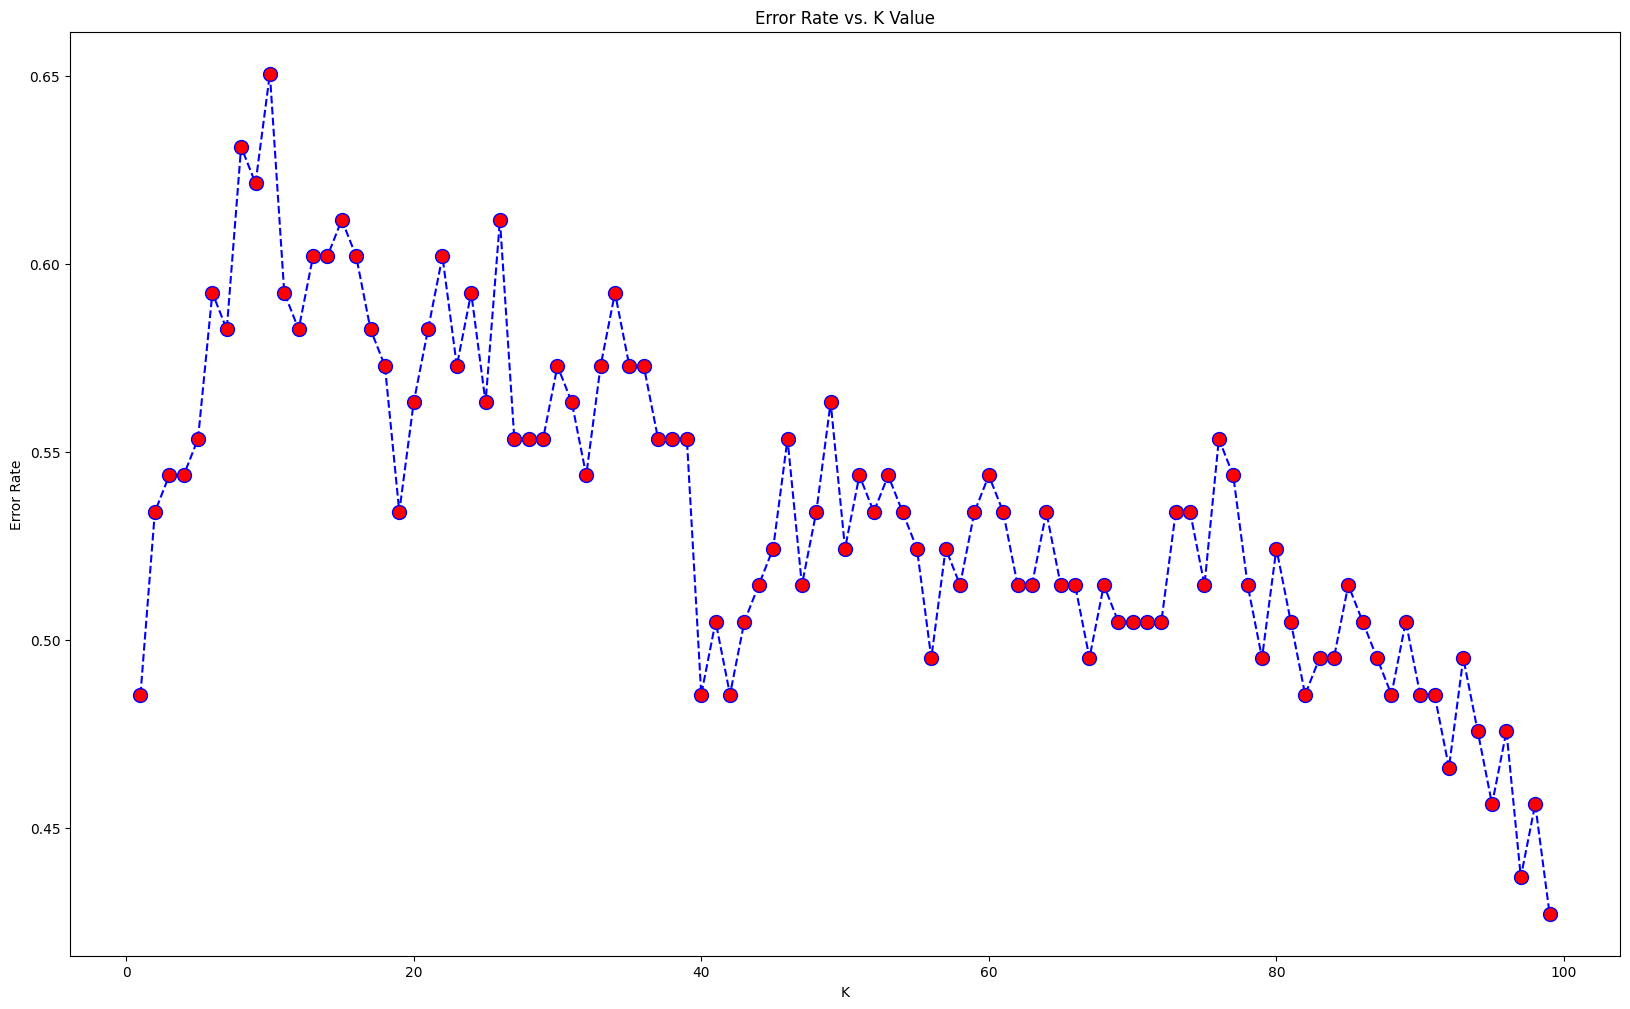

In [45]:
plt.figure(figsize=(20,12))
plt.plot(range(1,100),error_rate,color='blue', linestyle='dashed', marker='o',
         markerfacecolor='red', markersize=10)
plt.title('Error Rate vs. K Value')
plt.xlabel('K')
plt.ylabel('Error Rate')

In [46]:
knn_new = KNeighborsClassifier(n_neighbors=99)

In [47]:
knn_new.fit(X_frontal_train_features, y_frontal_train)

KNeighborsClassifier(n_neighbors=99)

In [48]:
predictions = knn_new.predict(X_frontal_test_features)

In [49]:
cm = confusion_matrix(y_frontal_test, predictions)
print("Confusion Matrix:\n", cm)
print("\n")
cf = classification_report(y_frontal_test, predictions)
print("Classification Report:\n", cf)
print("\n")
accuracy = accuracy_score(y_frontal_test, predictions)
print("Accuracy:", accuracy)

Confusion Matrix:
 [[33 21]
 [23 26]]


Classification Report:
               precision    recall  f1-score   support

           0       0.59      0.61      0.60        54
           1       0.55      0.53      0.54        49

    accuracy                           0.57       103
   macro avg       0.57      0.57      0.57       103
weighted avg       0.57      0.57      0.57       103



Accuracy: 0.5728155339805825


##### Best Accuracy: 59

### Occipital

In [50]:
from sklearn.ensemble import RandomForestClassifier

In [51]:
X_occipital_train_features.shape, y_occipital_train.shape

((349, 18), (349,))

In [52]:
# Instantiate model with 1000 decision trees
rf = RandomForestClassifier(n_estimators = 40, random_state = 42)
# Train the model on training data
rf.fit(X_occipital_train_features, y_occipital_train)

RandomForestClassifier(n_estimators=40, random_state=42)

In [53]:
predictions = rf.predict(X_occipital_test_features)

In [54]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score, classification_report
cm = confusion_matrix(y_occipital_test, predictions)
print("Confusion Matrix:\n", cm)
print("\n")
cf = classification_report(y_occipital_test, predictions)
print("Classification Report:\n", cf)
print("\n")
accuracy = accuracy_score(y_occipital_test, predictions)
print("Accuracy:", accuracy)

Confusion Matrix:
 [[22 32]
 [17 32]]


Classification Report:
               precision    recall  f1-score   support

           0       0.56      0.41      0.47        54
           1       0.50      0.65      0.57        49

    accuracy                           0.52       103
   macro avg       0.53      0.53      0.52       103
weighted avg       0.53      0.52      0.52       103



Accuracy: 0.5242718446601942


In [55]:
from sklearn.svm import SVC

In [56]:
model = SVC(C=1, kernel='rbf', gamma='scale', random_state=42) #default parameters
model.fit(X_occipital_train_features, y_occipital_train)

SVC(C=1, random_state=42)

In [57]:
predictions = model.predict(X_occipital_test_features)

In [58]:
cm = confusion_matrix(y_frontal_test, predictions)
print("Confusion Matrix:\n", cm)
print
cf = classification_report(y_frontal_test, predictions)
print("Classification Report:\n", cf)
print("\n")
accuracy = accuracy_score(y_frontal_test, predictions)
print("Accuracy:", accuracy)

Confusion Matrix:
 [[54  0]
 [49  0]]
Classification Report:
               precision    recall  f1-score   support

           0       0.52      1.00      0.69        54
           1       0.00      0.00      0.00        49

    accuracy                           0.52       103
   macro avg       0.26      0.50      0.34       103
weighted avg       0.27      0.52      0.36       103



Accuracy: 0.5242718446601942


c:\Users\suvan\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\suvan\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\suvan\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, mo

In [59]:
from xgboost import XGBClassifier

In [60]:
XGB = XGBClassifier(n_estimators=1000,learning_rate=0.05,max_depth=6,subsample=0.8,colsample_bytree=0.8,objective='multi:softmax',num_class=2,eval_metric='mlogloss',tree_method='auto')


In [61]:
XGB.fit(X_occipital_train_features, y_occipital_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='mlogloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=1000, n_jobs=None, num_class=2, ...)

In [62]:
occipital_predictions = XGB.predict(X_occipital_test_features)

In [63]:
cm = confusion_matrix(y_occipital_test, occipital_predictions)
print("Confusion Matrix:\n", cm)
print("\n")
cf = classification_report(y_occipital_test, occipital_predictions)
print("Classification Report:\n", cf)
print("\n")
accuracy = accuracy_score(y_occipital_test, occipital_predictions)
print("Accuracy:", accuracy)

Confusion Matrix:
 [[23 31]
 [19 30]]


Classification Report:
               precision    recall  f1-score   support

           0       0.55      0.43      0.48        54
           1       0.49      0.61      0.55        49

    accuracy                           0.51       103
   macro avg       0.52      0.52      0.51       103
weighted avg       0.52      0.51      0.51       103



Accuracy: 0.5145631067961165


Confusion Matrix:
 [[28 26]
 [21 28]]


Classification Report:
               precision    recall  f1-score   support

           0       0.57      0.52      0.54        54
           1       0.52      0.57      0.54        49

    accuracy                           0.54       103
   macro avg       0.54      0.54      0.54       103
weighted avg       0.55      0.54      0.54       103



Accuracy: 0.5436893203883495


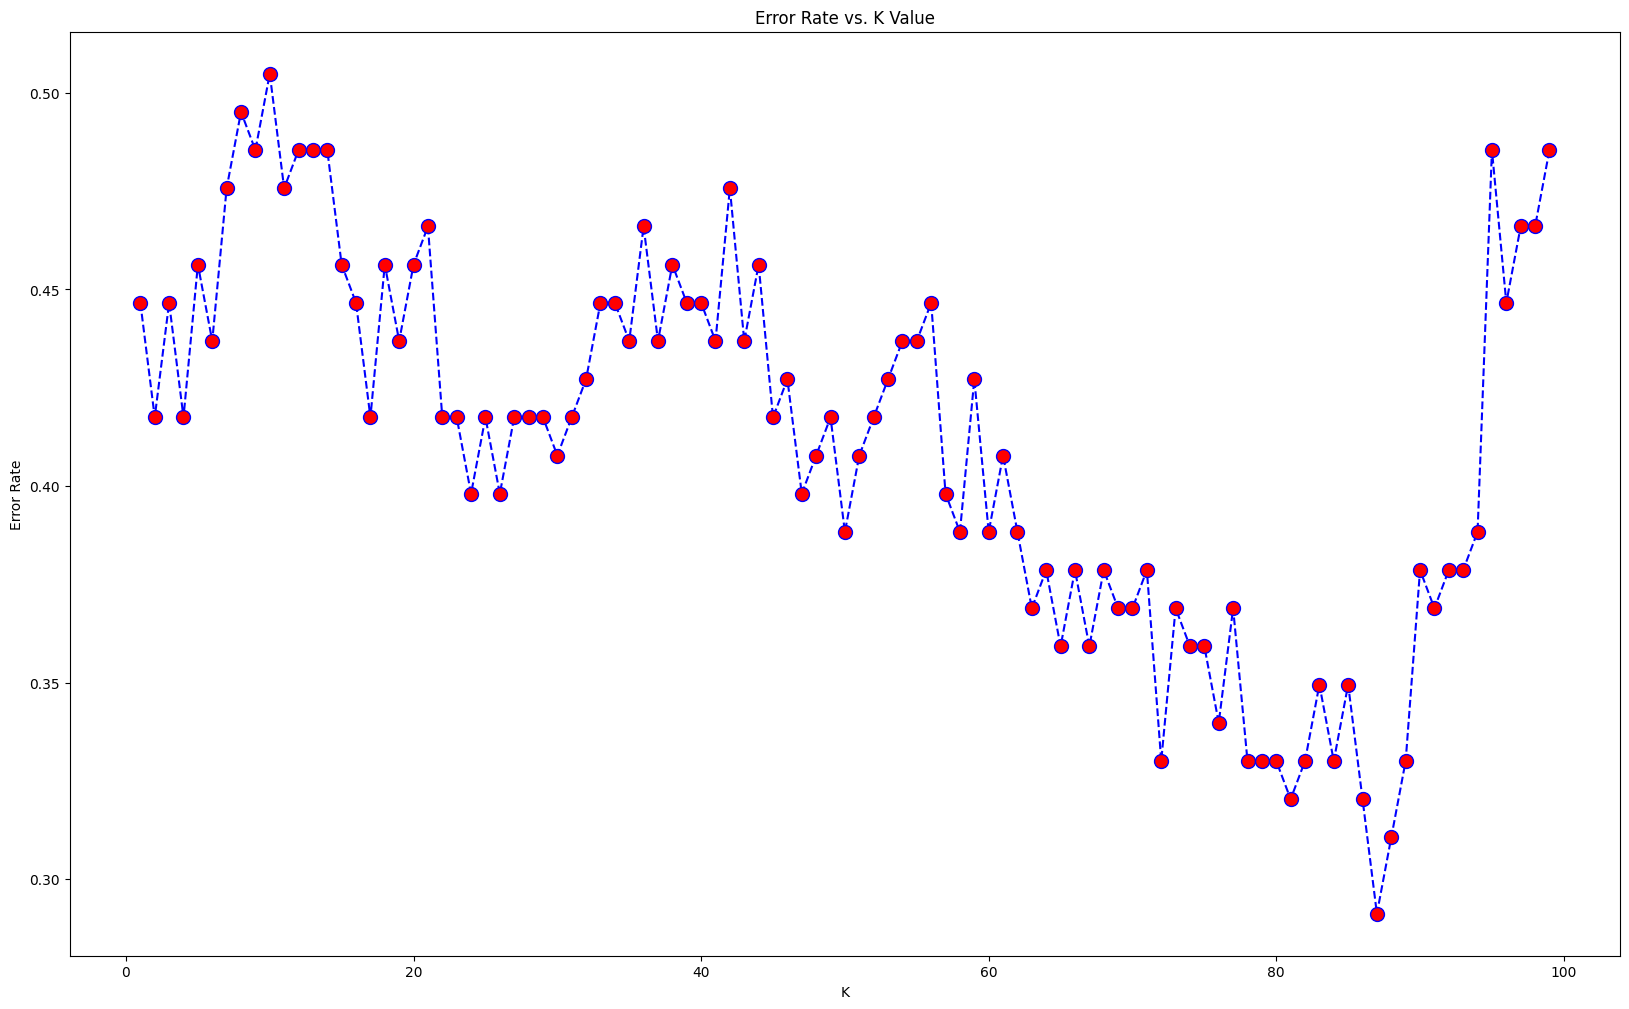

Confusion Matrix:
 [[17 37]
 [11 38]]


Classification Report:
               precision    recall  f1-score   support

           0       0.61      0.31      0.41        54
           1       0.51      0.78      0.61        49

    accuracy                           0.53       103
   macro avg       0.56      0.55      0.51       103
weighted avg       0.56      0.53      0.51       103



Accuracy: 0.5339805825242718


In [64]:
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_occipital_train_features, y_occipital_train)
predictions = knn.predict(X_occipital_test_features)
cm = confusion_matrix(y_occipital_test, predictions)
print("Confusion Matrix:\n", cm)
print("\n")
cf = classification_report(y_occipital_test, predictions)
print("Classification Report:\n", cf)
print("\n")
accuracy = accuracy_score(y_occipital_test, predictions)
print("Accuracy:", accuracy)

error_rate = []
for i in range(1,100):
    
    knn = KNeighborsClassifier(n_neighbors=i)
    knn.fit(X_occipital_train_features,y_occipital_train)
    pred_i = knn.predict(X_occipital_test_features)
    error_rate.append(np.mean(pred_i != y_occipital_test))
plt.figure(figsize=(20,12))
plt.plot(range(1,100),error_rate,color='blue', linestyle='dashed', marker='o',
         markerfacecolor='red', markersize=10)
plt.title('Error Rate vs. K Value')
plt.xlabel('K')
plt.ylabel('Error Rate')
plt.show()

knn_new = KNeighborsClassifier(n_neighbors=97)
knn_new.fit(X_occipital_train_features, y_occipital_train)
predictions = knn_new.predict(X_occipital_test_features)    
cm = confusion_matrix(y_occipital_test, predictions)
print("Confusion Matrix:\n", cm)
print("\n")
cf = classification_report(y_occipital_test, predictions)
print("Classification Report:\n", cf)
print("\n")
accuracy = accuracy_score(y_occipital_test, predictions)
print("Accuracy:", accuracy)

54

#### Parietal

In [65]:
X_parietal_train_features.shape, y_parietal_train.shape

((349, 126), (349,))

In [66]:
from sklearn.ensemble import RandomForestClassifier
# Instantiate model with 1000 decision trees
rf = RandomForestClassifier(n_estimators = 1000, random_state = 42)
# Train the model on training data
rf.fit(X_parietal_train_features, y_parietal_train)
predictions = rf.predict(X_parietal_test_features)
cm = confusion_matrix(y_parietal_test, predictions)
print("Confusion Matrix:\n", cm)
print("\n")
cf = classification_report(y_parietal_test, predictions)
print("Classification Report:\n", cf)
print("\n")
accuracy = accuracy_score(y_parietal_test, predictions)
print("Accuracy:", accuracy)

Confusion Matrix:
 [[29 25]
 [20 29]]


Classification Report:
               precision    recall  f1-score   support

           0       0.59      0.54      0.56        54
           1       0.54      0.59      0.56        49

    accuracy                           0.56       103
   macro avg       0.56      0.56      0.56       103
weighted avg       0.57      0.56      0.56       103



Accuracy: 0.5631067961165048


In [67]:
from sklearn.svm import SVC
model = SVC(C=1, kernel='rbf', gamma='scale', random_state=42) #default parameters
model.fit(X_parietal_train_features, y_parietal_train)
parietal_predictions = model.predict(X_parietal_test_features)
cm = confusion_matrix(y_parietal_test, parietal_predictions)
print("Confusion Matrix:\n", cm)
print("\n")
cf = classification_report(y_parietal_test, parietal_predictions)
print("Classification Report:\n", cf)
print("\n")
accuracy = accuracy_score(y_parietal_test, parietal_predictions)
print("Accuracy:", accuracy)

Confusion Matrix:
 [[54  0]
 [49  0]]


Classification Report:
               precision    recall  f1-score   support

           0       0.52      1.00      0.69        54
           1       0.00      0.00      0.00        49

    accuracy                           0.52       103
   macro avg       0.26      0.50      0.34       103
weighted avg       0.27      0.52      0.36       103



Accuracy: 0.5242718446601942


c:\Users\suvan\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\suvan\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\suvan\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, mo

In [68]:
from xgboost import XGBClassifier
XGB = XGBClassifier(n_estimators=1000,learning_rate=0.05,max_depth=6,subsample=0.8,colsample_bytree=0.8,objective='multi:softmax',num_class=2,eval_metric='mlogloss',tree_method='auto')
XGB.fit(X_parietal_train_features, y_parietal_train)
predictions = XGB.predict(X_parietal_test_features)
cm = confusion_matrix(y_parietal_test, predictions)
print("Confusion Matrix:\n", cm)
print("\n")
cf = classification_report(y_parietal_test, predictions)
print("Classification Report:\n", cf)
print("\n")
accuracy = accuracy_score(y_parietal_test, predictions) 
print("Accuracy:", accuracy)

Confusion Matrix:
 [[33 21]
 [21 28]]


Classification Report:
               precision    recall  f1-score   support

           0       0.61      0.61      0.61        54
           1       0.57      0.57      0.57        49

    accuracy                           0.59       103
   macro avg       0.59      0.59      0.59       103
weighted avg       0.59      0.59      0.59       103



Accuracy: 0.5922330097087378


Confusion Matrix:
 [[23 31]
 [26 23]]


Classification Report:
               precision    recall  f1-score   support

           0       0.47      0.43      0.45        54
           1       0.43      0.47      0.45        49

    accuracy                           0.45       103
   macro avg       0.45      0.45      0.45       103
weighted avg       0.45      0.45      0.45       103



Accuracy: 0.44660194174757284




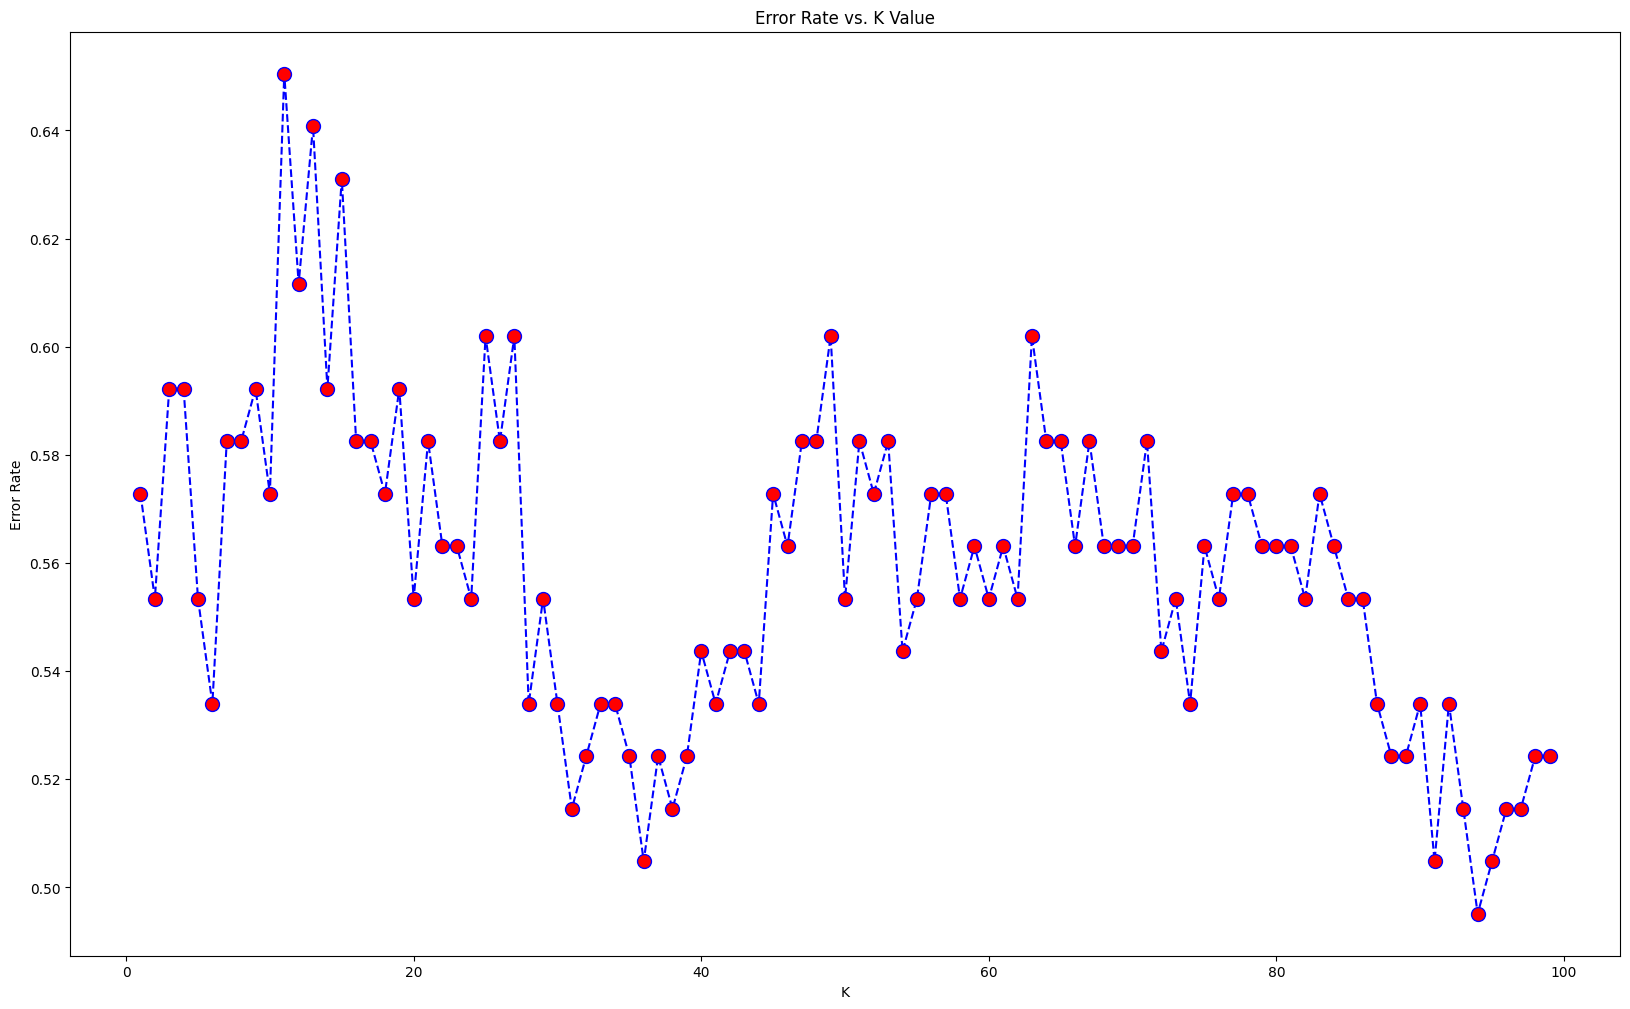

Confusion Matrix:
 [[ 9 45]
 [13 36]]


Classification Report:
               precision    recall  f1-score   support

           0       0.41      0.17      0.24        54
           1       0.44      0.73      0.55        49

    accuracy                           0.44       103
   macro avg       0.43      0.45      0.40       103
weighted avg       0.43      0.44      0.39       103



Accuracy: 0.4368932038834951


In [69]:
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_parietal_train_features, y_parietal_train)
predictions = knn.predict(X_parietal_test_features)
cm = confusion_matrix(y_parietal_test, predictions)
print("Confusion Matrix:\n", cm)
print("\n")
cf = classification_report(y_parietal_test, predictions)
print("Classification Report:\n", cf)
print("\n")
accuracy = accuracy_score(y_parietal_test, predictions)
print("Accuracy:", accuracy)
print("\n")

error_rate = []
for i in range(1,100):
    
    knn = KNeighborsClassifier(n_neighbors=i)
    knn.fit(X_parietal_train_features,y_parietal_train)
    pred_i = knn.predict(X_parietal_test_features)
    error_rate.append(np.mean(pred_i != y_parietal_test))   
plt.figure(figsize=(20,12))
plt.plot(range(1,100),error_rate,color='blue', linestyle='dashed', marker='o',
         markerfacecolor='red', markersize=10)
plt.title('Error Rate vs. K Value')
plt.xlabel('K')
plt.ylabel('Error Rate')
plt.show()

knn_new = KNeighborsClassifier(n_neighbors=81)
knn_new.fit(X_parietal_train_features, y_parietal_train)
predictions = knn_new.predict(X_parietal_test_features)
cm = confusion_matrix(y_parietal_test, predictions)
print("Confusion Matrix:\n", cm)
print("\n")
cf = classification_report(y_parietal_test, predictions)    
print("Classification Report:\n", cf)
print("\n")
accuracy = accuracy_score(y_parietal_test, predictions)
print("Accuracy:", accuracy)

59

#### temporal

In [70]:
X_temporal_train_features.shape, y_temporal_train.shape

((349, 48), (349,))

In [71]:
from sklearn.ensemble import RandomForestClassifier
# Instantiate model with 1000 decision trees
rf = RandomForestClassifier(n_estimators = 1000, random_state = 42)
# Train the model on training data
rf.fit(X_temporal_train_features, y_temporal_train)
temporal_predictions = rf.predict(X_temporal_test_features)
cm = confusion_matrix(y_temporal_test, temporal_predictions)
print("Confusion Matrix:\n", cm)
print("\n")
cf = classification_report(y_temporal_test, temporal_predictions)
print("Classification Report:\n", cf)
print("\n")
accuracy = accuracy_score(y_temporal_test, temporal_predictions)
print("Accuracy:", accuracy)

Confusion Matrix:
 [[47  7]
 [26 23]]


Classification Report:
               precision    recall  f1-score   support

           0       0.64      0.87      0.74        54
           1       0.77      0.47      0.58        49

    accuracy                           0.68       103
   macro avg       0.71      0.67      0.66       103
weighted avg       0.70      0.68      0.67       103



Accuracy: 0.6796116504854369


In [72]:
from sklearn.svm import SVC
model = SVC(C=1, kernel='rbf', gamma='scale', random_state=42) #default parameters
model.fit(X_temporal_train_features, y_temporal_train)
temporal_predictions = model.predict(X_temporal_test_features)
cm = confusion_matrix(y_temporal_test, temporal_predictions)
print("Confusion Matrix:\n", cm)
print("\n")
cf = classification_report(y_temporal_test, temporal_predictions)
print("Classification Report:\n", cf)
print("\n")
accuracy = accuracy_score(y_temporal_test, temporal_predictions)
print("Accuracy:", accuracy)

Confusion Matrix:
 [[54  0]
 [49  0]]


Classification Report:
               precision    recall  f1-score   support

           0       0.52      1.00      0.69        54
           1       0.00      0.00      0.00        49

    accuracy                           0.52       103
   macro avg       0.26      0.50      0.34       103
weighted avg       0.27      0.52      0.36       103



Accuracy: 0.5242718446601942


c:\Users\suvan\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\suvan\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\suvan\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, mo

In [73]:
from xgboost import XGBClassifier
XGB = XGBClassifier(n_estimators=1000,learning_rate=0.05,max_depth=6,subsample=0.8,colsample_bytree=0.8,objective='multi:softmax',num_class=2,eval_metric='mlogloss',tree_method='auto')
XGB.fit(X_temporal_train_features, y_temporal_train)
predictions = XGB.predict(X_temporal_test_features)
cm = confusion_matrix(y_temporal_test, predictions)
print("Confusion Matrix:\n", cm)
print("\n")
cf = classification_report(y_temporal_test, predictions)
print("Classification Report:\n", cf)
print("\n")
accuracy = accuracy_score(y_temporal_test, predictions)
print("Accuracy:", accuracy)

Confusion Matrix:
 [[47  7]
 [26 23]]


Classification Report:
               precision    recall  f1-score   support

           0       0.64      0.87      0.74        54
           1       0.77      0.47      0.58        49

    accuracy                           0.68       103
   macro avg       0.71      0.67      0.66       103
weighted avg       0.70      0.68      0.67       103



Accuracy: 0.6796116504854369


70

#### Central

In [74]:
X_central_train_features.shape, y_central_train.shape

((349, 42), (349,))

In [75]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators = 1000, random_state = 42)
rf.fit(X_central_train_features, y_central_train)
central_predictions = rf.predict(X_central_test_features)
cm = confusion_matrix(y_central_test, central_predictions)
print("Confusion Matrix:\n", cm)
print("\n")
cf = classification_report(y_central_test, central_predictions)
print("Classification Report:\n", cf)
print("\n")
accuracy = accuracy_score(y_central_test, central_predictions)
print("Accuracy:", accuracy)

Confusion Matrix:
 [[33 21]
 [14 35]]


Classification Report:
               precision    recall  f1-score   support

           0       0.70      0.61      0.65        54
           1       0.62      0.71      0.67        49

    accuracy                           0.66       103
   macro avg       0.66      0.66      0.66       103
weighted avg       0.67      0.66      0.66       103



Accuracy: 0.6601941747572816


In [76]:
from sklearn.svm import SVC
model = SVC(C=1, kernel='rbf', gamma='scale', random_state=42) #default parameters
model.fit(X_central_train_features, y_central_train)  
central_predictions = model.predict(X_central_test_features)
cm = confusion_matrix(y_central_test, central_predictions)
print("Confusion Matrix:\n", cm)
print("\n")
cf = classification_report(y_central_test, central_predictions)
print("Classification Report:\n", cf)
print("\n")
accuracy = accuracy_score(y_central_test, central_predictions)
print("Accuracy:", accuracy)

Confusion Matrix:
 [[24 30]
 [20 29]]


Classification Report:
               precision    recall  f1-score   support

           0       0.55      0.44      0.49        54
           1       0.49      0.59      0.54        49

    accuracy                           0.51       103
   macro avg       0.52      0.52      0.51       103
weighted avg       0.52      0.51      0.51       103



Accuracy: 0.5145631067961165


In [77]:
from xgboost import XGBClassifier
XGB = XGBClassifier(n_estimators=1000,learning_rate=0.05,max_depth=6,subsample=0.8,colsample_bytree=0.8,objective='multi:softmax',num_class=2,eval_metric='mlogloss',tree_method='auto')
XGB.fit(X_central_train_features, y_central_train)
predictions = XGB.predict(X_central_test_features)
cm = confusion_matrix(y_central_test, predictions)
print("Confusion Matrix:\n", cm)
print("\n")
cf = classification_report(y_central_test, predictions)
print("Classification Report:\n", cf)
print("\n")
accuracy = accuracy_score(y_central_test, predictions)
print("Accuracy:", accuracy)

Confusion Matrix:
 [[39 15]
 [20 29]]


Classification Report:
               precision    recall  f1-score   support

           0       0.66      0.72      0.69        54
           1       0.66      0.59      0.62        49

    accuracy                           0.66       103
   macro avg       0.66      0.66      0.66       103
weighted avg       0.66      0.66      0.66       103



Accuracy: 0.6601941747572816


Confusion Matrix:
 [[26 28]
 [11 38]]


Classification Report:
               precision    recall  f1-score   support

           0       0.70      0.48      0.57        54
           1       0.58      0.78      0.66        49

    accuracy                           0.62       103
   macro avg       0.64      0.63      0.62       103
weighted avg       0.64      0.62      0.61       103



Accuracy: 0.6213592233009708




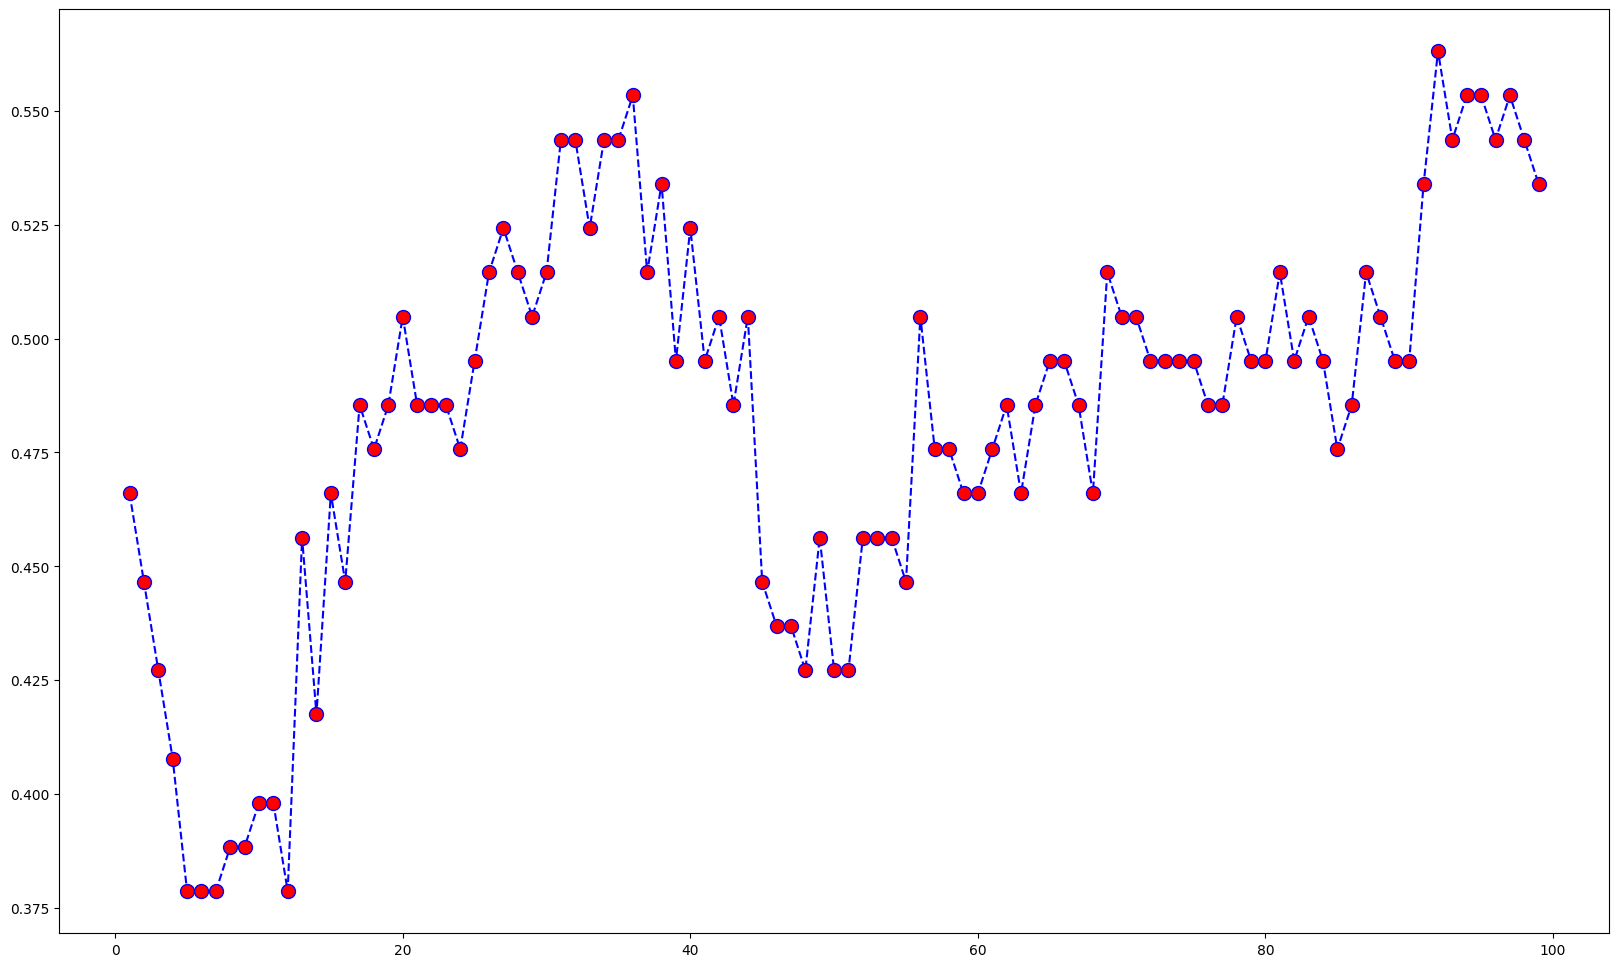

Confusion Matrix:
 [[28 26]
 [17 32]]


Classification Report:
               precision    recall  f1-score   support

           0       0.62      0.52      0.57        54
           1       0.55      0.65      0.60        49

    accuracy                           0.58       103
   macro avg       0.59      0.59      0.58       103
weighted avg       0.59      0.58      0.58       103



Accuracy: 0.5825242718446602


In [78]:
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_central_train_features, y_central_train)
predictions = knn.predict(X_central_test_features)
cm = confusion_matrix(y_central_test, predictions)
print("Confusion Matrix:\n", cm)
print("\n")
cf = classification_report(y_central_test, predictions)
print("Classification Report:\n", cf)
print("\n")
accuracy = accuracy_score(y_central_test, predictions)
print("Accuracy:", accuracy)
print("\n")
error_rate = []
for i in range(1,100):
    knn = KNeighborsClassifier(n_neighbors=i)
    knn.fit(X_central_train_features,y_central_train)
    pred_i = knn.predict(X_central_test_features)
    error_rate.append(np.mean(pred_i != y_central_test))
plt.figure(figsize=(20,12))
plt.plot(range(1,100),error_rate,color='blue', linestyle='dashed', marker='o',
         markerfacecolor='red', markersize=10)
plt.show()

knn_new = KNeighborsClassifier(n_neighbors=14)
knn_new.fit(X_central_train_features, y_central_train)
predictions = knn_new.predict(X_central_test_features)
cm = confusion_matrix(y_central_test, predictions)
print("Confusion Matrix:\n", cm)
print("\n")
cf = classification_report(y_central_test, predictions)    
print("Classification Report:\n", cf)
print("\n")
accuracy = accuracy_score(y_central_test, predictions)
print("Accuracy:", accuracy)

67